In [1]:
import numpy as np

In [4]:
class AdalineSGD:
    def __init__(self, eta = 0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        # Initialize parameters
        seed = np.random.RandomState(self.random_state)
        self.w = seed.normal(loc = 0.0, scale = 0.01, size = X.shape[1])

        self.b = np.float64(0.0)
        self.losses = []

        for i in range(self.n_iter):
            idx = np.random.permutation(len(X))
            X, y = X[idx], y[idx]
            epoch_losses = []

            for Xi, target in zip(X, y):
                Zi = np.dot(Xi, self.w) + self.b
                error = target - Zi
                delta_w = self.eta * error * Xi
                delta_b = self.eta * error

                self.w += delta_w
                self.b += delta_b
                epoch_losses.append(error**2)
            
            self.losses.append(np.mean(epoch_losses))

        return self




    def net_input(self, X):
        return np.dot(X, self.w) + self.b
    
    def activation(self, X):
        return X
    
    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [2]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/'\
    'machine-learning-databases/iris/iris.data'

print(s)

df = pd.read_csv(s, header = None, encoding = 'utf-8')

import matplotlib.pyplot as plt

y = df.iloc[0:100, 4] # 행 0 ~ 99, 5번째 column
y = np.where(y == "Iris-setosa", 0, 1) # setosa -> 0, versicolor -> 1
X = df.iloc[0:100, [0, 2]].values

https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


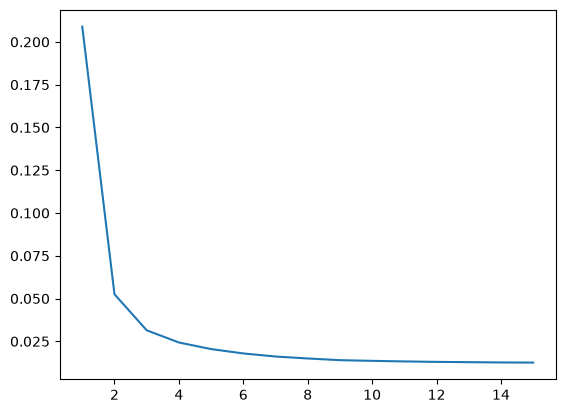

In [5]:
ada_sgd = AdalineSGD(n_iter = 15, eta = 0.01, random_state=1)
X_std = np.zeros_like(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

ada_sgd.fit(X_std, y)
plt.plot(range(1, len(ada_sgd.losses) + 1), ada_sgd.losses)